# Nuremberg Feature Exploratory Data Analysis

Comprehensive analysis of **1,800 engineered features** for ~30K grid cells in Nuremberg.
Features are derived from Sentinel-2 (optical) and Sentinel-1 (SAR) satellite imagery across 2 years x 3 seasons.

**Feature groups:**
- **S2 Reflectance Bands** (B02-B12, B8A): 10 bands x 7 stats x 6 year-season = 420 features
- **Spectral Indices** (NDVI, NDWI, NDBI, EVI2, ...): 15 indices x 5 stats x 6 = 450 features
- **SAR Backscatter** (VV, VH, Cross-Ratio): 336 temporal/seasonal features
- **Texture & Tasseled Cap** (edge, laplacian, TC brightness/greenness/wetness): ~500 features
- **Coverage** (finite_frac): 60 data quality features

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import re

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

PROJECT = Path('.').resolve()
while not (PROJECT / 'data' / 'cities').exists() and PROJECT != PROJECT.parent:
    PROJECT = PROJECT.parent

CITIES_DIR = PROJECT / 'data' / 'cities'
DIAG_DIR = PROJECT / 'mlp' / 'diagrams'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

# ESA WorldCover class definitions
CLASS_NAMES = ['tree_cover', 'shrubland', 'grassland', 'cropland', 'built_up', 'bare_sparse', 'water']
CLASS_LABELS = ['Tree Cover', 'Shrubland', 'Grassland', 'Cropland', 'Built-up', 'Bare/Sparse', 'Water']
CLASS_COLORS = ['#2d6a4f', '#a3b18a', '#6a994e', '#f4a261', '#e76f51', '#d4a373', '#0096c7']

print('Project root:', PROJECT)

Project root: C:\Users\vanya\Documents\ML_1_sem\final


## 1. Load Nuremberg Features & Labels

In [2]:
# Load features and labels
feat = pd.read_parquet(CITIES_DIR / 'nuremberg' / 'features_v7' / 'features_rust_2020_2021.parquet')
lab = pd.read_parquet(CITIES_DIR / 'nuremberg' / 'labels_2021.parquet')

# Merge and assign dominant class
df = feat.merge(lab[['cell_id'] + CLASS_NAMES], on='cell_id', how='inner')
df['label'] = df[CLASS_NAMES].values.argmax(axis=1)
df['label_name'] = df['label'].map(dict(enumerate(CLASS_LABELS)))

# Feature columns only
meta_cols = {'cell_id', 'valid_fraction', 'low_valid_fraction'} | set(CLASS_NAMES) | {'label', 'label_name'}
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f'Nuremberg: {len(df):,} grid cells x {len(feature_cols):,} features')
print(f'\nClass distribution:')
for i, (name, label) in enumerate(zip(CLASS_NAMES, CLASS_LABELS)):
    n = (df.label == i).sum()
    print(f'  {label:15s}: {n:6,} cells ({n/len(df)*100:5.1f}%)')

Nuremberg: 29,946 grid cells x 1,800 features

Class distribution:
  Tree Cover     : 14,354 cells ( 47.9%)
  Shrubland      :      0 cells (  0.0%)
  Grassland      :  2,240 cells (  7.5%)
  Cropland       :  3,129 cells ( 10.4%)
  Built-up       :  9,948 cells ( 33.2%)
  Bare/Sparse    :     28 cells (  0.1%)
  Water          :    247 cells (  0.8%)


## 2. Feature Inventory

In [3]:
# Parse features into groups
def parse_feature(col):
    # SAR temporal features (no season)
    m = re.match(r'(SAR_\w+)_(temporal_std|temporal_cv|summer_winter)_(\d{4})$', col)
    if m:
        return m.group(1), m.group(2), m.group(3), 'temporal'
    # Standard pattern: NAME_stat_year_season
    m = re.match(r'([A-Za-z0-9_]+?)_(mean|std|min|max|q25|median|q75|finite_frac)_(\d{4})_(spring|summer|autumn|winter)$', col)
    if m:
        return m.groups()
    return None, None, None, None

parsed = pd.DataFrame([parse_feature(c) for c in feature_cols],
                      columns=['band', 'stat', 'year', 'season'], index=feature_cols)
parsed = parsed.dropna(subset=['band'])

# Group bands into categories
S2_BANDS = {'B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12'}
VEG_INDICES = {'NDVI','NDWI','NDBI','NDMI','NBR','BSI','EVI2','SAVI','GNDVI','NDRE1','NDRE2','NDTI','CRI1','IRECI','MNDWI'}
SAR_BANDS = {b for b in parsed.band.unique() if b.startswith('SAR')}
TEXTURE = {'edge','lap'} | {b for b in parsed.band.unique() if b.startswith('TC_')}

cats = {}
for idx, row in parsed.iterrows():
    if row.band in S2_BANDS:
        cats[idx] = 'S2 Reflectance'
    elif row.band in VEG_INDICES:
        cats[idx] = 'Spectral Index'
    elif row.band in SAR_BANDS:
        cats[idx] = 'SAR Backscatter'
    elif row.band in TEXTURE:
        cats[idx] = 'Texture/TC'
    elif row.stat == 'finite_frac':
        cats[idx] = 'Coverage'
    else:
        cats[idx] = 'Other'

parsed['category'] = pd.Series(cats)

print('Feature categories:')
for cat, grp in parsed.groupby('category'):
    bands = sorted(grp.band.unique())
    print(f'  {cat:20s}: {len(grp):4d} features  ({", ".join(bands[:8])}{"..." if len(bands) > 8 else ""})')
print(f'  {"TOTAL":20s}: {len(parsed):4d}')

Feature categories:
  Other               :    6 features  (lap_abs)
  S2 Reflectance      :  480 features  (B02, B03, B04, B05, B06, B07, B08, B11...)
  SAR Backscatter     :  172 features  (SAR_CR, SAR_RVI, SAR_VH, SAR_VV)
  Spectral Index      :  450 features  (BSI, CRI1, EVI2, GNDVI, IRECI, MNDWI, NBR, NDBI...)
  Texture/TC          :   60 features  (TC_bright, TC_green, TC_wet, edge, lap)
  TOTAL               : 1168


## 3. Data Quality: Missing Values & Coverage

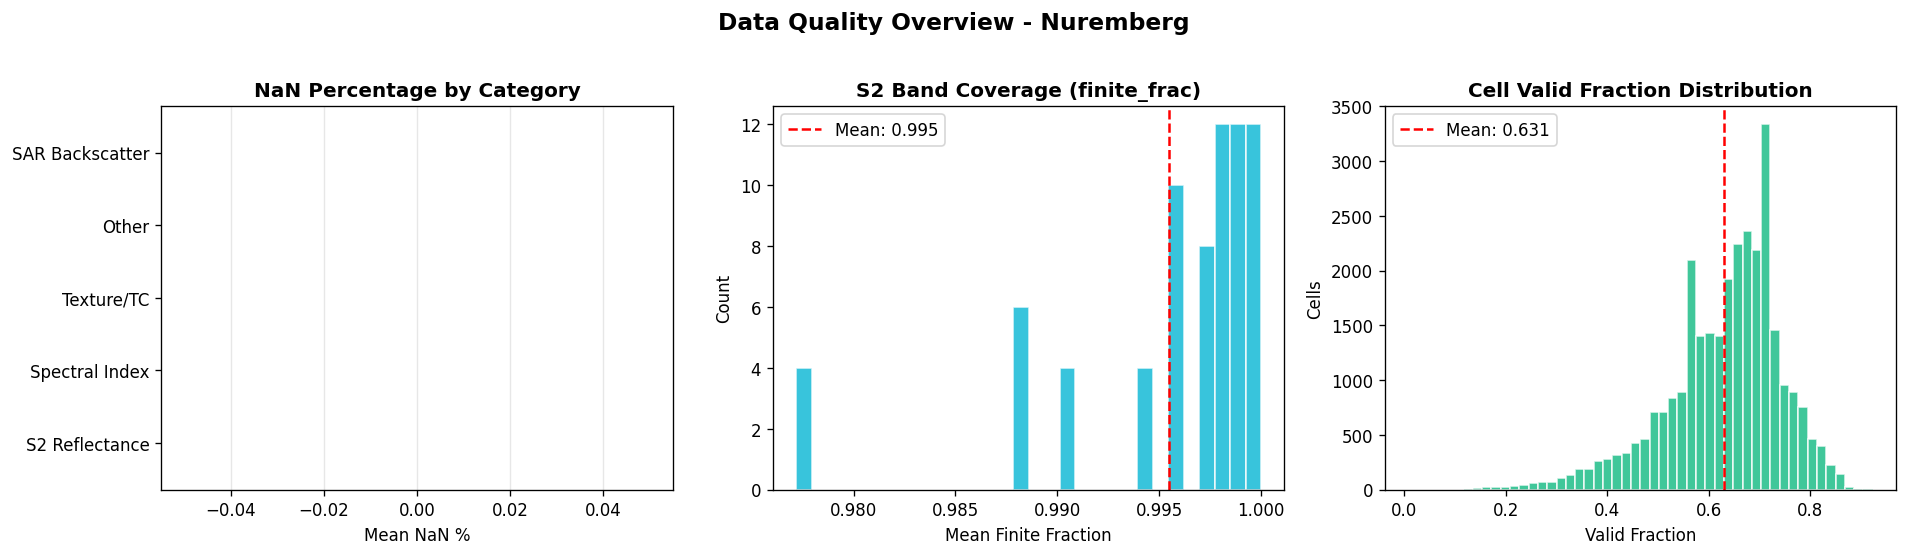

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 3a: NaN % per category
nan_by_cat = {}
for cat in parsed.category.unique():
    cat_cols = parsed[parsed.category == cat].index.tolist()
    nan_pct = df[cat_cols].isna().mean().mean() * 100
    nan_by_cat[cat] = nan_pct

ax = axes[0]
cats_sorted = sorted(nan_by_cat.items(), key=lambda x: -x[1])
ax.barh([c[0] for c in cats_sorted], [c[1] for c in cats_sorted], color='#8b5cf6', alpha=0.8)
ax.set_xlabel('Mean NaN %')
ax.set_title('NaN Percentage by Category', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3b: finite_frac distribution
finite_cols = [c for c in feature_cols if 'finite_frac' in c]
if finite_cols:
    ax = axes[1]
    finite_means = df[finite_cols].mean()
    ax.hist(finite_means, bins=30, color='#06b6d4', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Mean Finite Fraction')
    ax.set_ylabel('Count')
    ax.set_title('S2 Band Coverage (finite_frac)', fontweight='bold')
    ax.axvline(finite_means.mean(), color='red', ls='--', label=f'Mean: {finite_means.mean():.3f}')
    ax.legend()

# 3c: valid_fraction
ax = axes[2]
ax.hist(df['valid_fraction'], bins=50, color='#10b981', alpha=0.8, edgecolor='white')
ax.set_xlabel('Valid Fraction')
ax.set_ylabel('Cells')
ax.set_title('Cell Valid Fraction Distribution', fontweight='bold')
ax.axvline(df['valid_fraction'].mean(), color='red', ls='--', label=f'Mean: {df["valid_fraction"].mean():.3f}')
ax.legend()

plt.suptitle('Data Quality Overview - Nuremberg', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Class Distribution

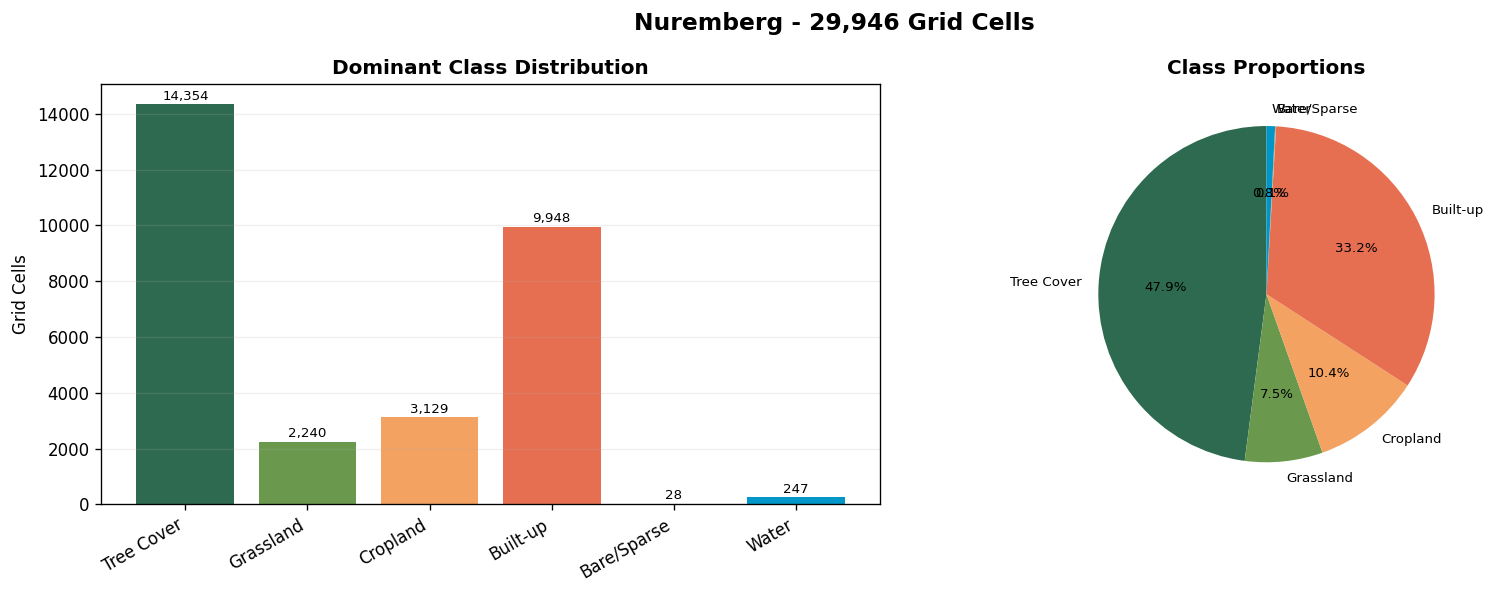

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
counts = df.label.value_counts().sort_index()
bars = ax.bar(range(len(counts)), counts.values, color=[CLASS_COLORS[i] for i in counts.index])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([CLASS_LABELS[i] for i in counts.index], rotation=30, ha='right')
ax.set_ylabel('Grid Cells')
ax.set_title('Dominant Class Distribution', fontweight='bold')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{cnt:,}', ha='center', va='bottom', fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# Pie chart
ax = axes[1]
ax.pie(counts.values, labels=[CLASS_LABELS[i] for i in counts.index],
       colors=[CLASS_COLORS[i] for i in counts.index],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax.set_title('Class Proportions', fontweight='bold')

plt.suptitle(f'Nuremberg - {len(df):,} Grid Cells', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_nuremberg_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. S2 Reflectance Band Analysis

Per-class distributions of Sentinel-2 reflectance bands (mean values, summer 2021).
These are the raw spectral measurements at different wavelengths.

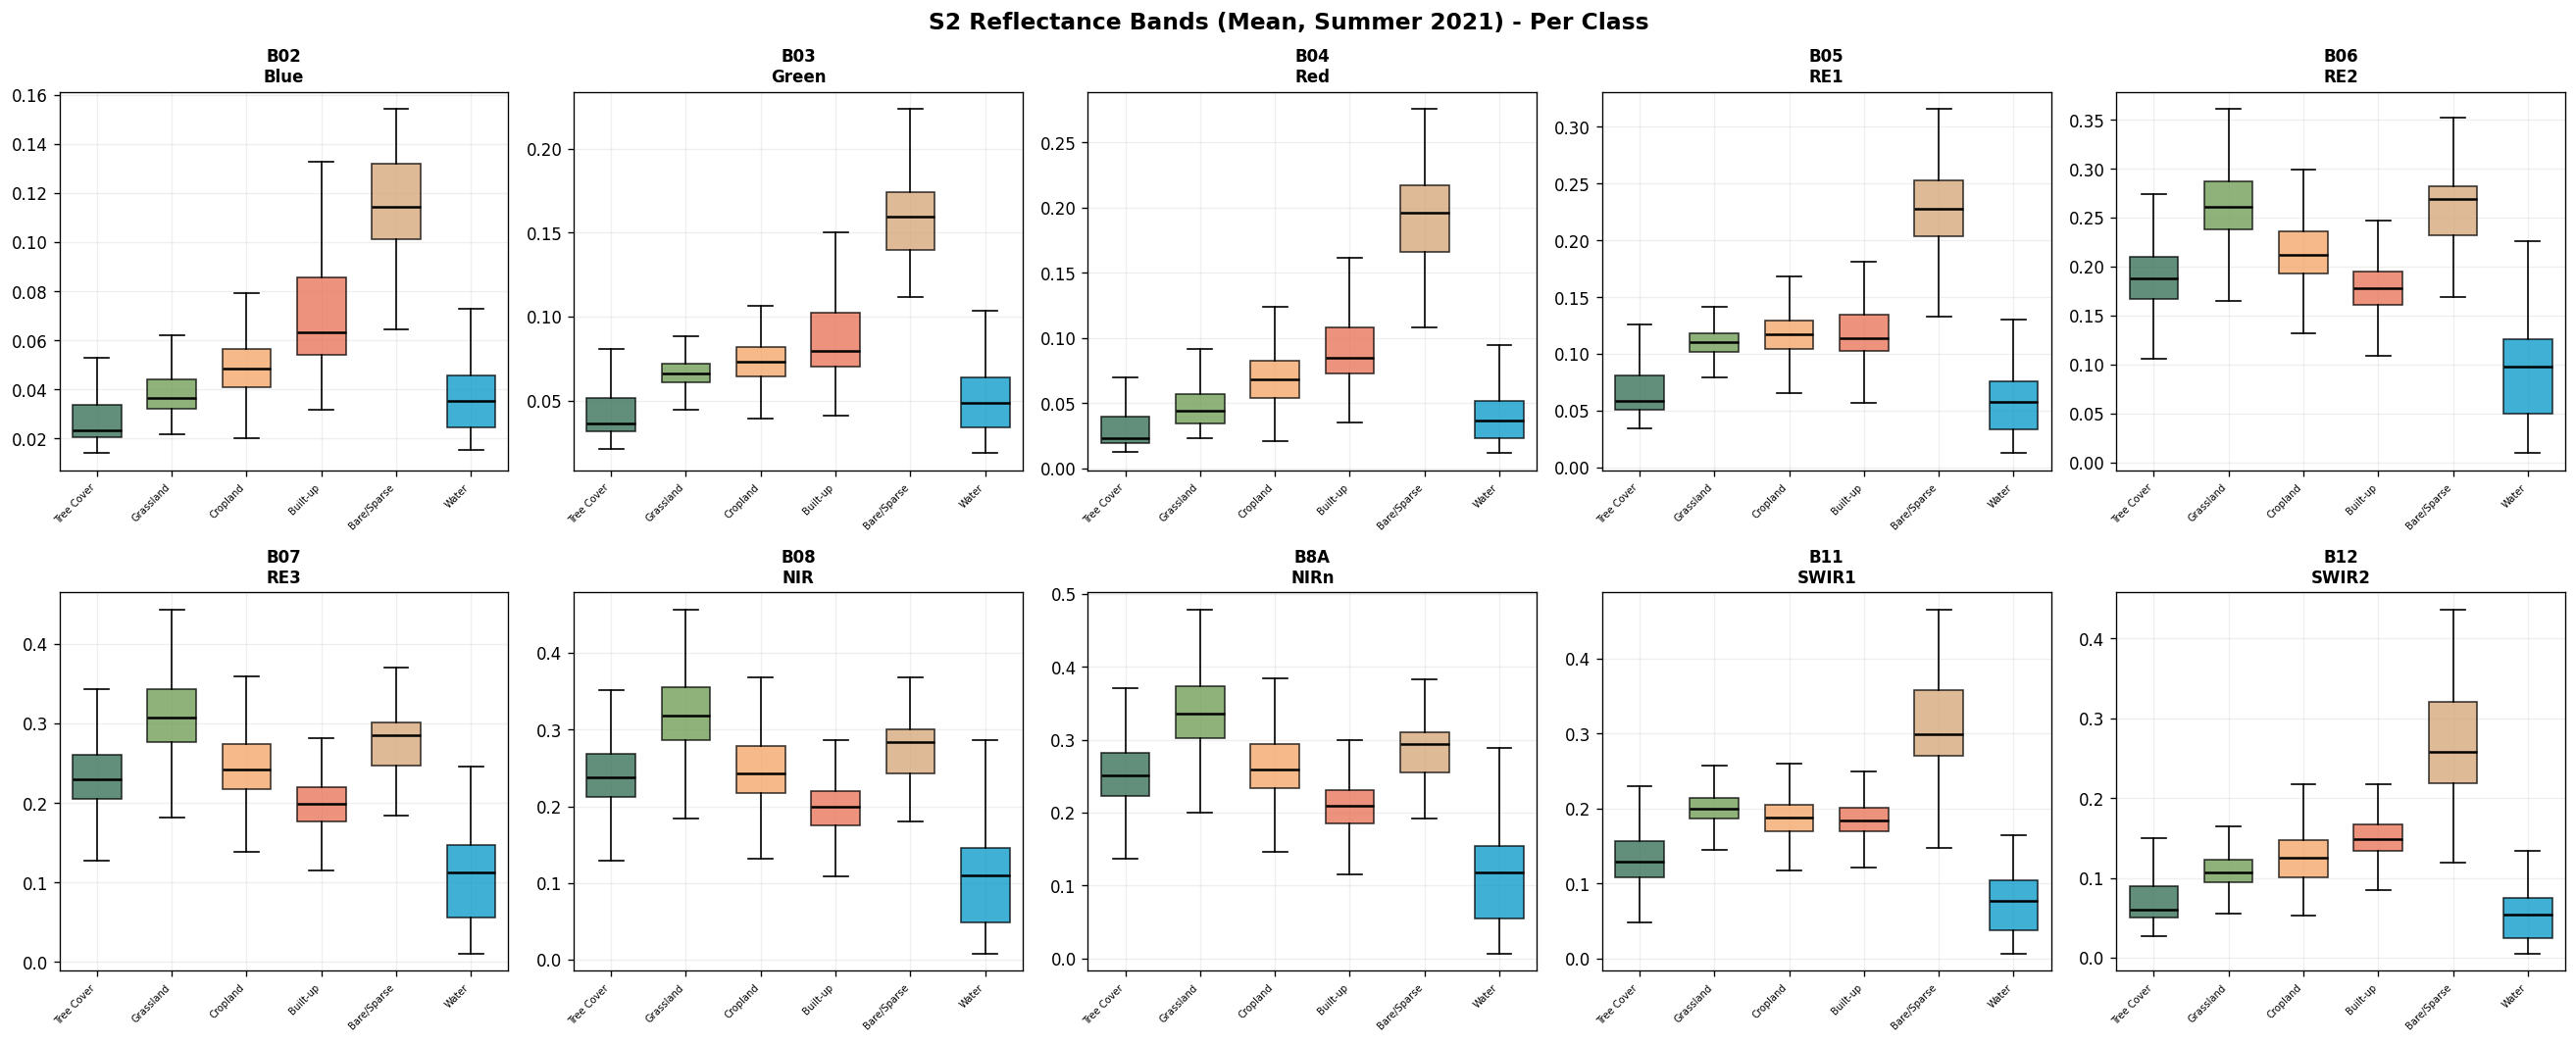

In [6]:
s2_bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
s2_labels = ['B02\nBlue', 'B03\nGreen', 'B04\nRed', 'B05\nRE1', 'B06\nRE2',
             'B07\nRE3', 'B08\nNIR', 'B8A\nNIRn', 'B11\nSWIR1', 'B12\nSWIR2']

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharey=False)
axes_flat = axes.flatten()

classes = sorted(df.label.unique())
class_labels_used = [CLASS_LABELS[c] for c in classes]
colors_used = [CLASS_COLORS[c] for c in classes]

for ax, band, blabel in zip(axes_flat, s2_bands, s2_labels):
    col = f'{band}_mean_2021_summer'
    if col not in df.columns:
        continue
    data = [df.loc[df.label == c, col].dropna().values for c in classes]
    data = [d for d in data if len(d) > 0]

    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.65)
    for patch, co in zip(bp['boxes'], colors_used):
        patch.set_facecolor(co)
        patch.set_alpha(0.75)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1.5)

    ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=6)
    ax.set_title(blabel, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle('S2 Reflectance Bands (Mean, Summer 2021) - Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_s2_bands.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Spectral Vegetation / Water / Built-up Indices

Key spectral indices derived from S2 bands. Each index highlights different surface properties:
- **NDVI**: vegetation vigor (high = dense vegetation)
- **NDWI**: water content (high = water bodies)
- **NDBI**: built-up density (high = urban)
- **EVI2**: enhanced vegetation (less saturated than NDVI)
- **NDMI**: moisture stress

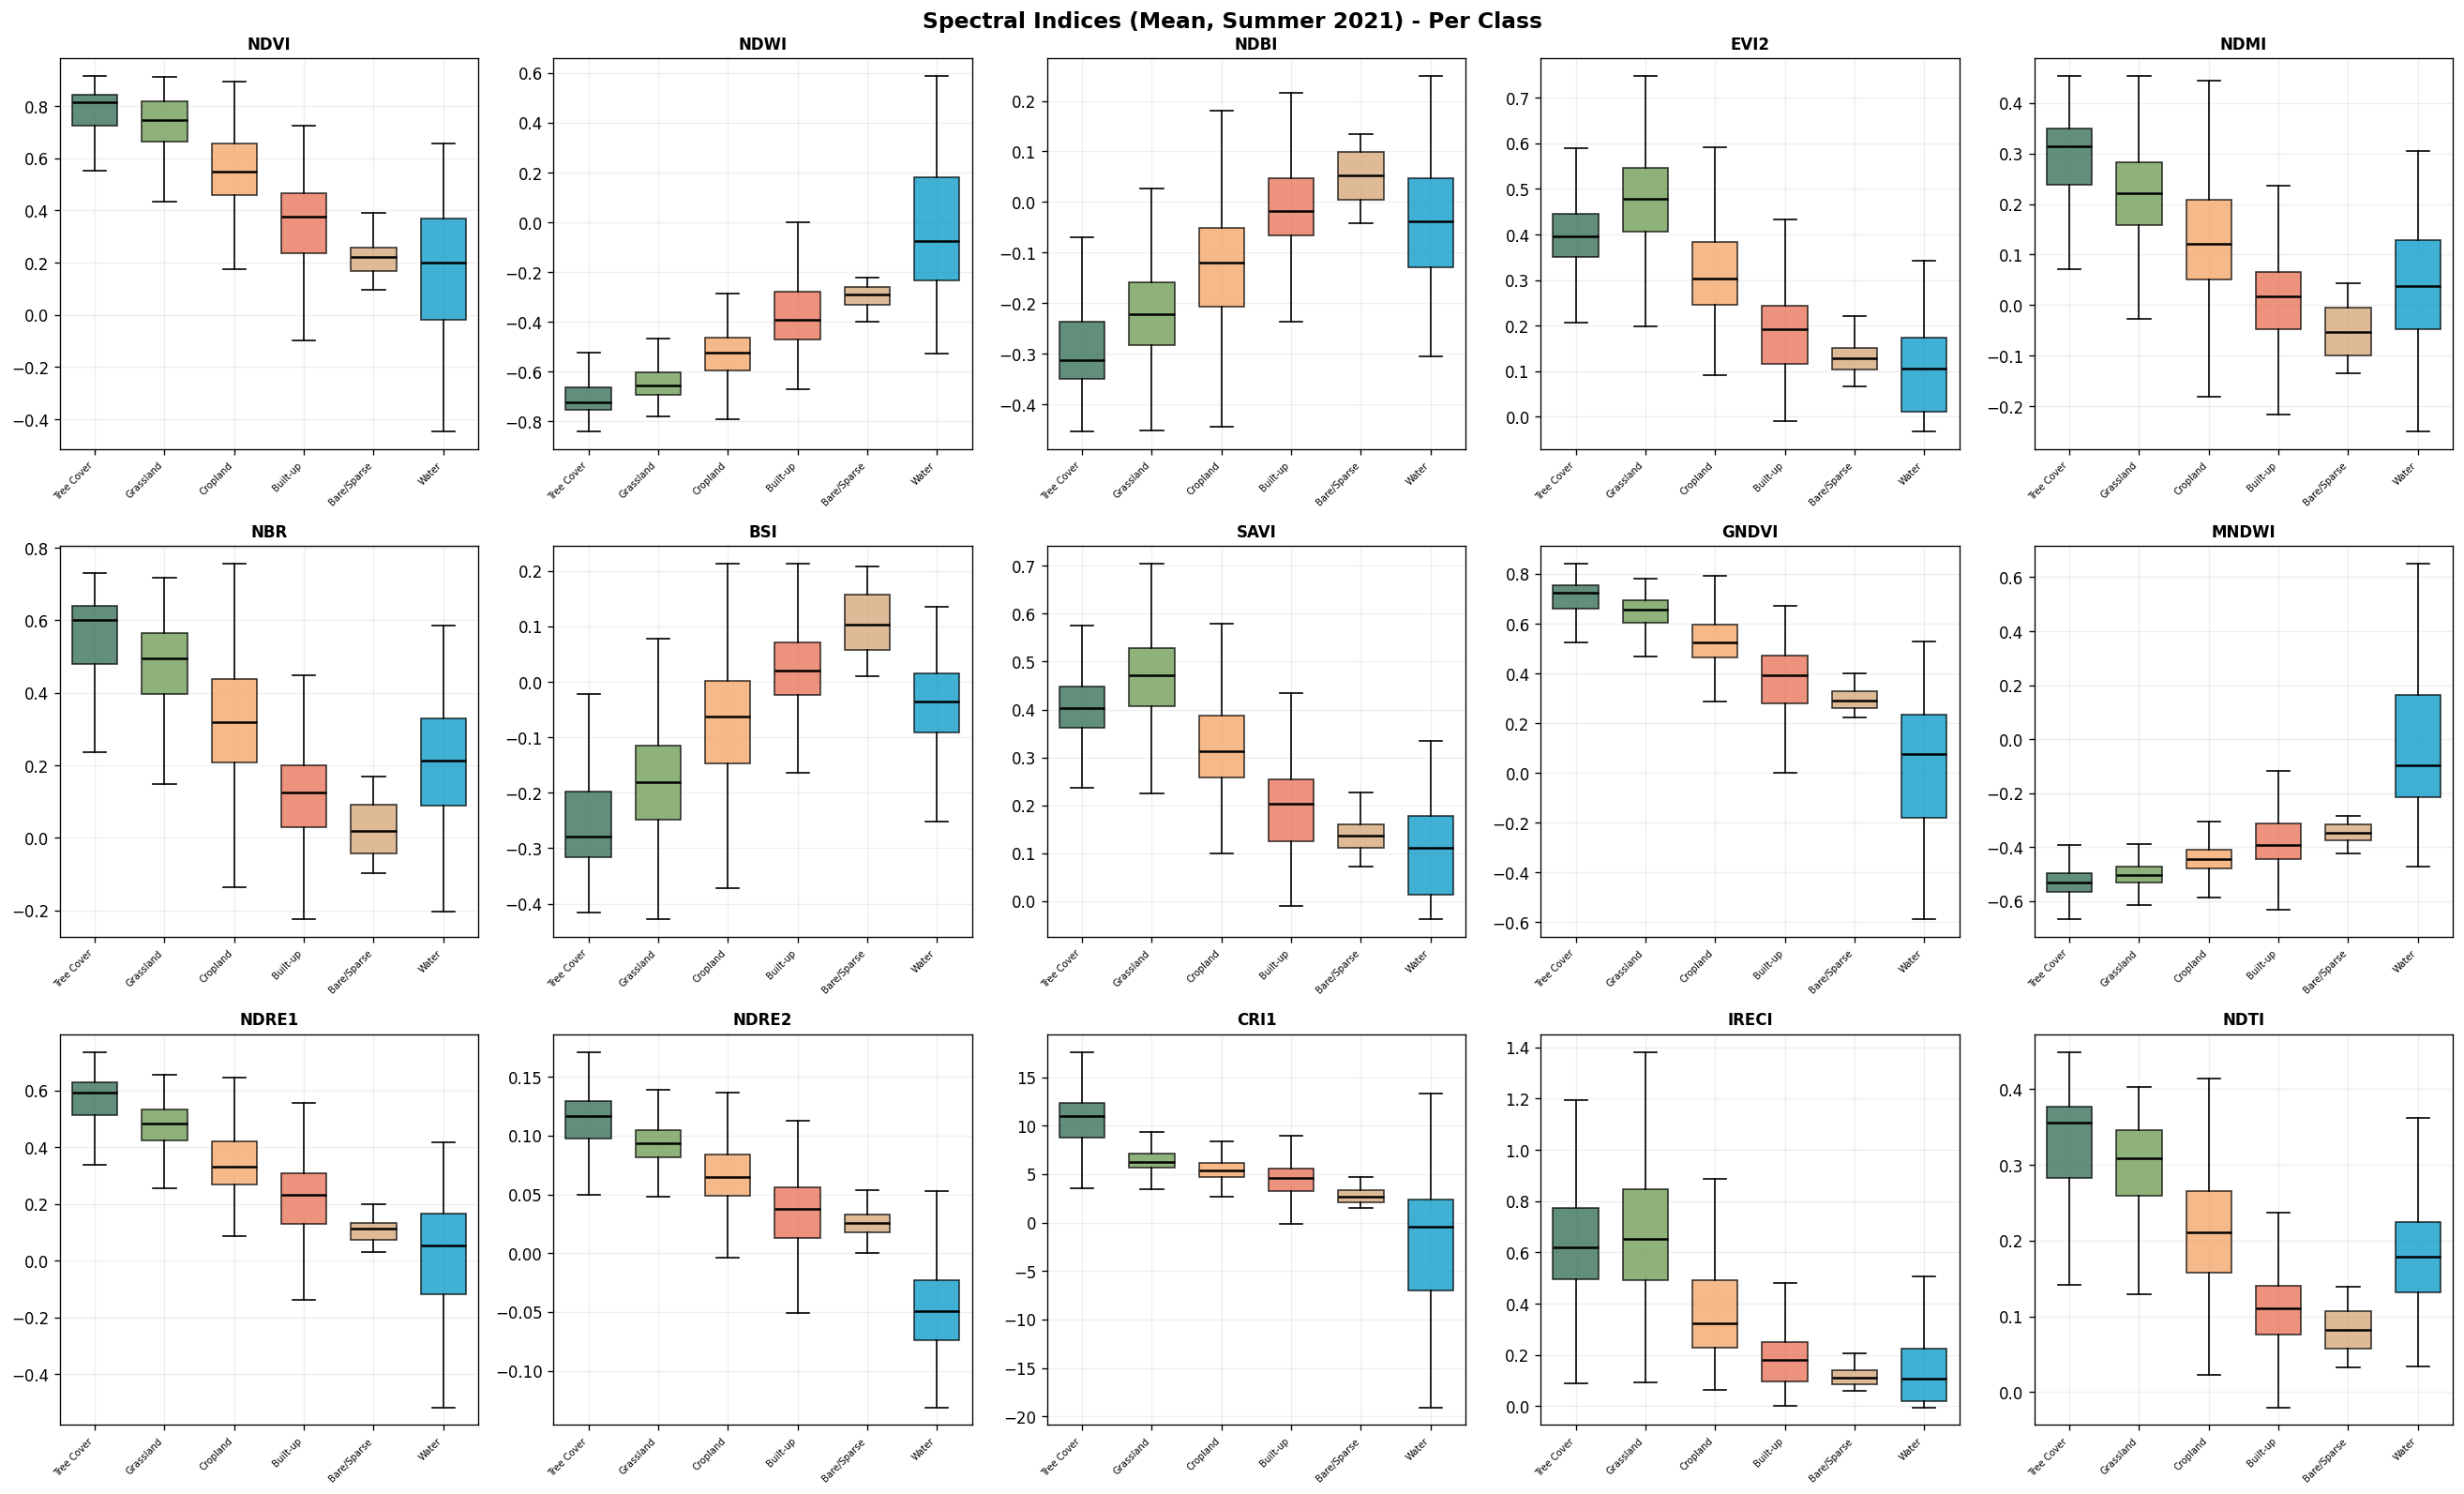

In [7]:
indices = ['NDVI', 'NDWI', 'NDBI', 'EVI2', 'NDMI', 'NBR', 'BSI', 'SAVI', 'GNDVI', 'MNDWI', 'NDRE1', 'NDRE2', 'CRI1', 'IRECI', 'NDTI']
available = [idx for idx in indices if f'{idx}_mean_2021_summer' in df.columns]

n_idx = len(available)
ncols = 5
nrows = (n_idx + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4.5 * nrows))
axes_flat = axes.flatten()

for ax, idx_name in zip(axes_flat, available):
    col = f'{idx_name}_mean_2021_summer'
    data = [df.loc[df.label == c, col].dropna().values for c in classes]
    data = [d for d in data if len(d) > 0]

    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.65)
    for patch, co in zip(bp['boxes'], colors_used):
        patch.set_facecolor(co)
        patch.set_alpha(0.75)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1.5)

    ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=6)
    ax.set_title(idx_name, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)

for i in range(len(available), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Spectral Indices (Mean, Summer 2021) - Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Seasonal Phenology (NDVI across seasons)

How NDVI varies across spring/summer/autumn reveals seasonal crop cycles and deciduous vs evergreen patterns.

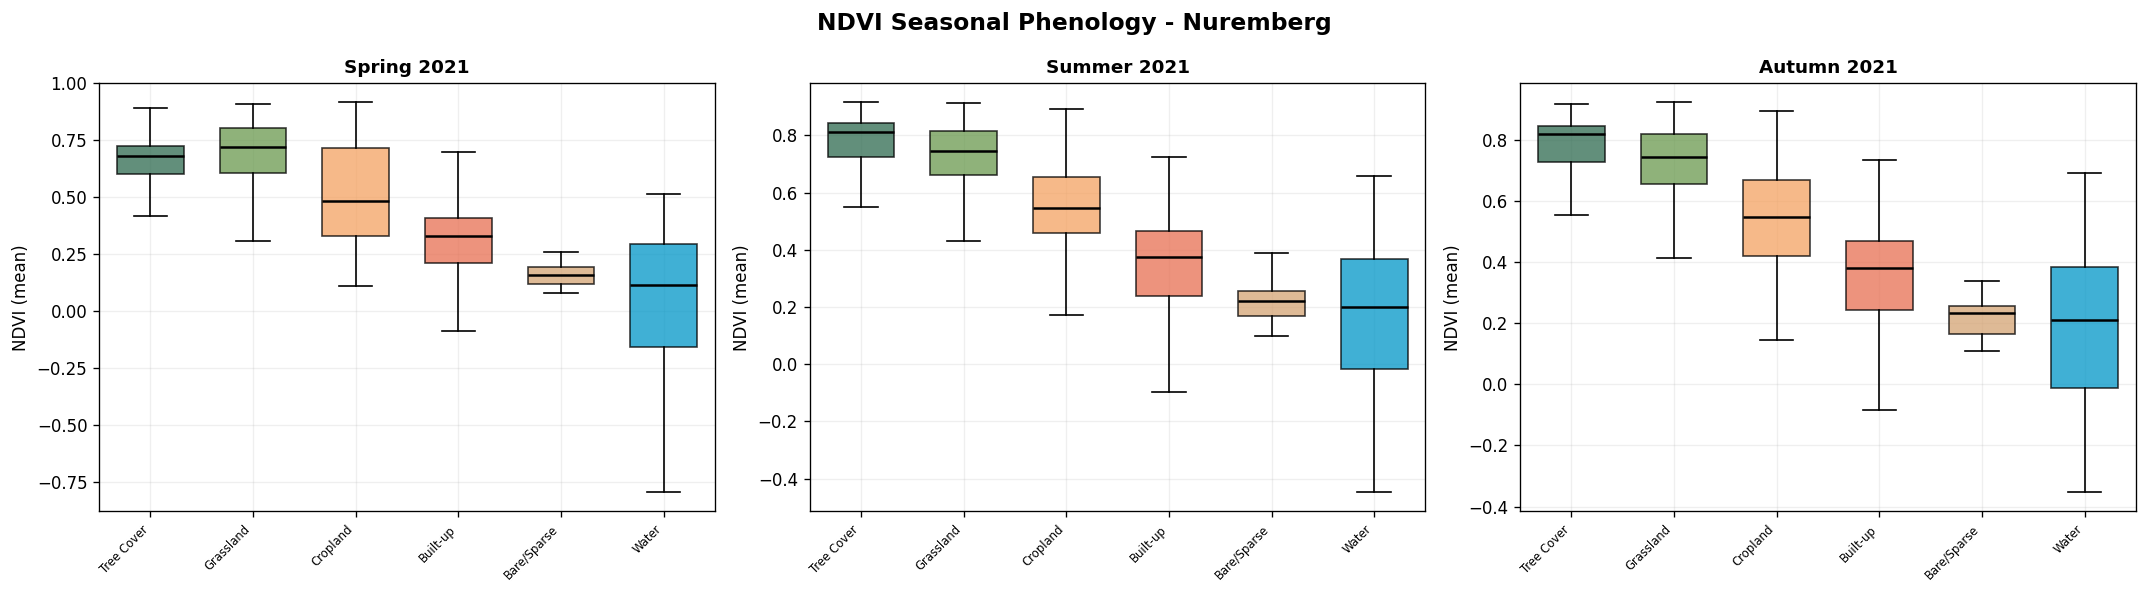

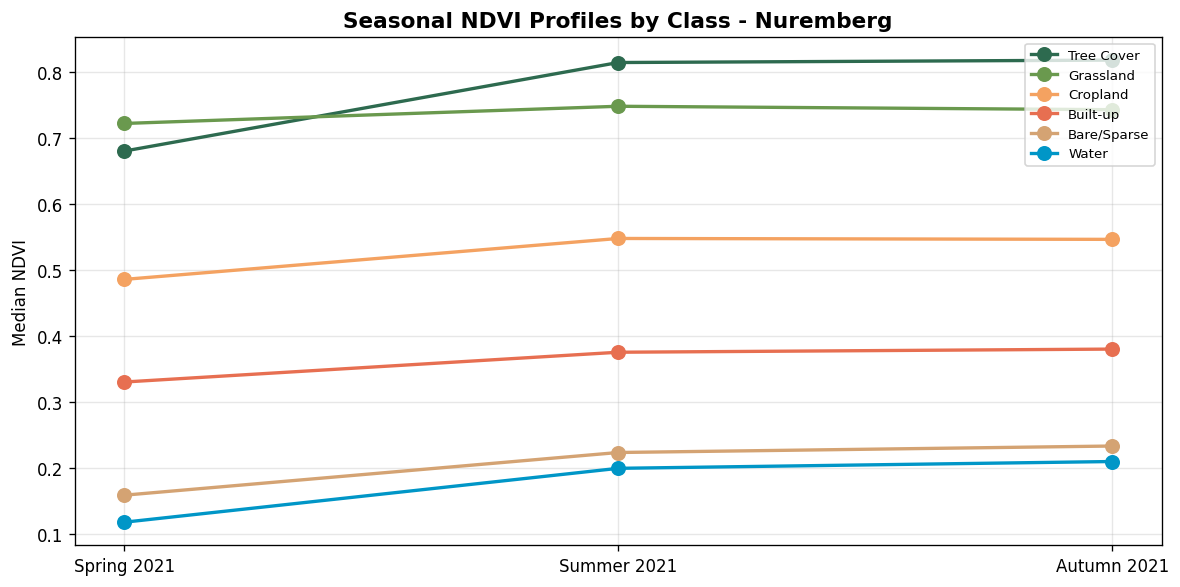

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seasons_2021 = ['spring', 'summer', 'autumn']
season_labels = ['Spring 2021', 'Summer 2021', 'Autumn 2021']

for ax, season, slabel in zip(axes, seasons_2021, season_labels):
    col = f'NDVI_mean_2021_{season}'
    if col not in df.columns:
        continue
    data = [df.loc[df.label == c, col].dropna().values for c in classes]
    data_f = [d for d in data if len(d) > 0]

    bp = ax.boxplot(data_f, patch_artist=True, showfliers=False, widths=0.65)
    for patch, co in zip(bp['boxes'], colors_used):
        patch.set_facecolor(co)
        patch.set_alpha(0.75)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1.5)

    ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=7)
    ax.set_title(slabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('NDVI (mean)')
    ax.grid(True, alpha=0.2)

plt.suptitle('NDVI Seasonal Phenology - Nuremberg', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_ndvi_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# Seasonal line profiles
fig, ax = plt.subplots(figsize=(10, 5))
for c, name, color in zip(classes, class_labels_used, colors_used):
    means = []
    for season in seasons_2021:
        col = f'NDVI_mean_2021_{season}'
        if col in df.columns:
            means.append(df.loc[df.label == c, col].median())
    ax.plot(season_labels, means, '-o', color=color, label=name, linewidth=2, markersize=8)

ax.set_ylabel('Median NDVI')
ax.set_title('Seasonal NDVI Profiles by Class - Nuremberg', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_ndvi_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SAR Backscatter (Sentinel-1)

Sentinel-1 SAR data is weather-independent (penetrates clouds).
- **VV**: co-polarized backscatter (sensitive to surface roughness)
- **VH**: cross-polarized backscatter (sensitive to volume scattering / vegetation)
- **Cross-Ratio (CR)**: VH/VV ratio, indicates depolarization

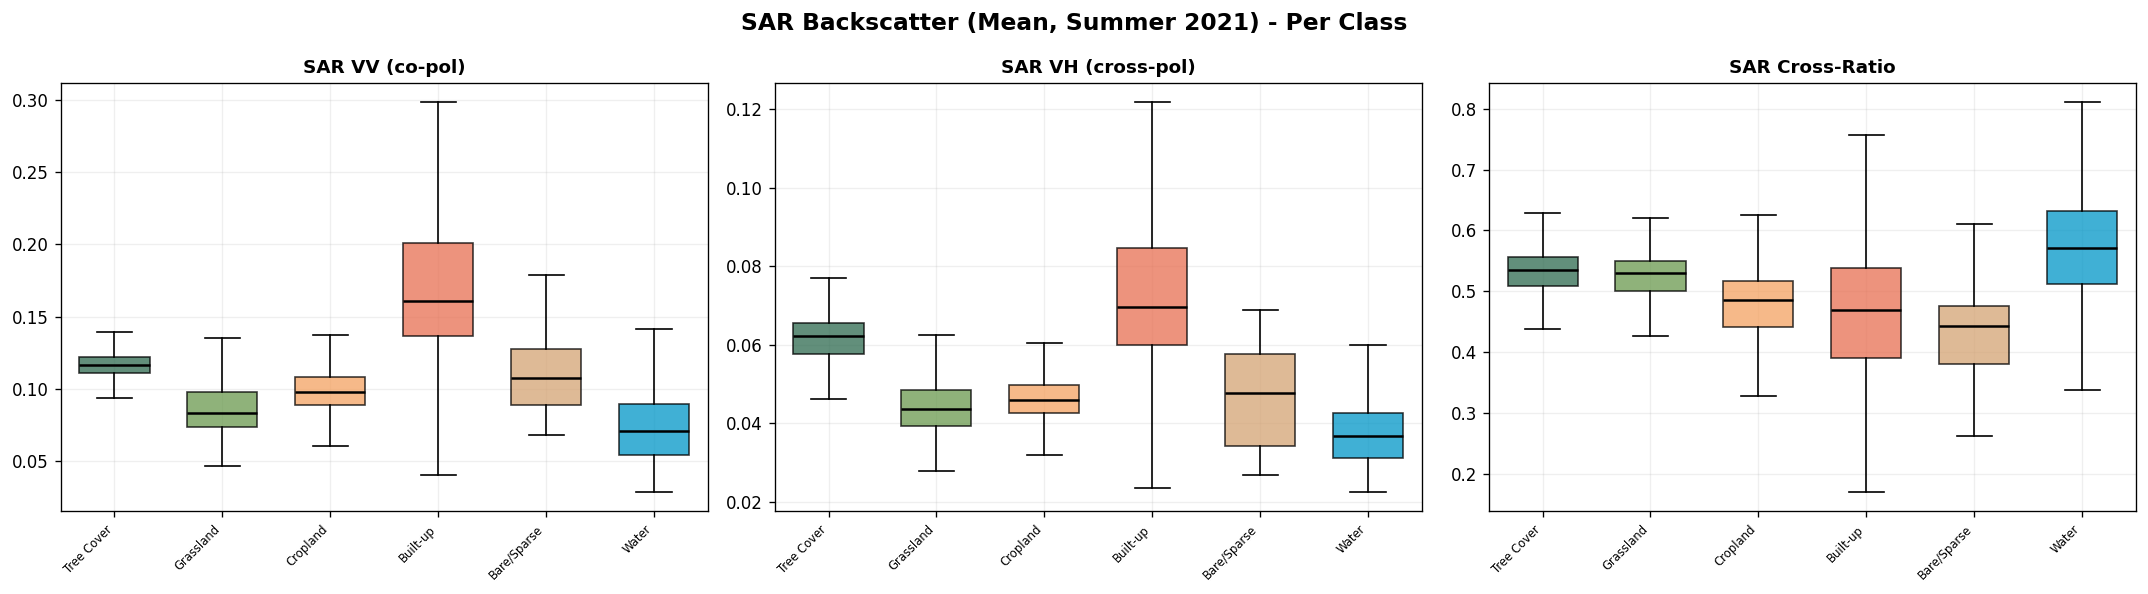

In [9]:
sar_feats = ['SAR_VV', 'SAR_VH', 'SAR_CR']
sar_labels_nice = ['VV (co-pol)', 'VH (cross-pol)', 'Cross-Ratio']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sf, sl in zip(axes, sar_feats, sar_labels_nice):
    col = f'{sf}_mean_2021_summer'
    if col not in df.columns:
        continue
    data = [df.loc[df.label == c, col].dropna().values for c in classes]
    data_f = [d for d in data if len(d) > 0]

    bp = ax.boxplot(data_f, patch_artist=True, showfliers=False, widths=0.65)
    for patch, co in zip(bp['boxes'], colors_used):
        patch.set_facecolor(co)
        patch.set_alpha(0.75)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1.5)

    ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'SAR {sl}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle('SAR Backscatter (Mean, Summer 2021) - Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_sar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SAR Temporal Features

Temporal variability (std, CV) and summer-winter contrasts in SAR data reveal dynamic surface changes.

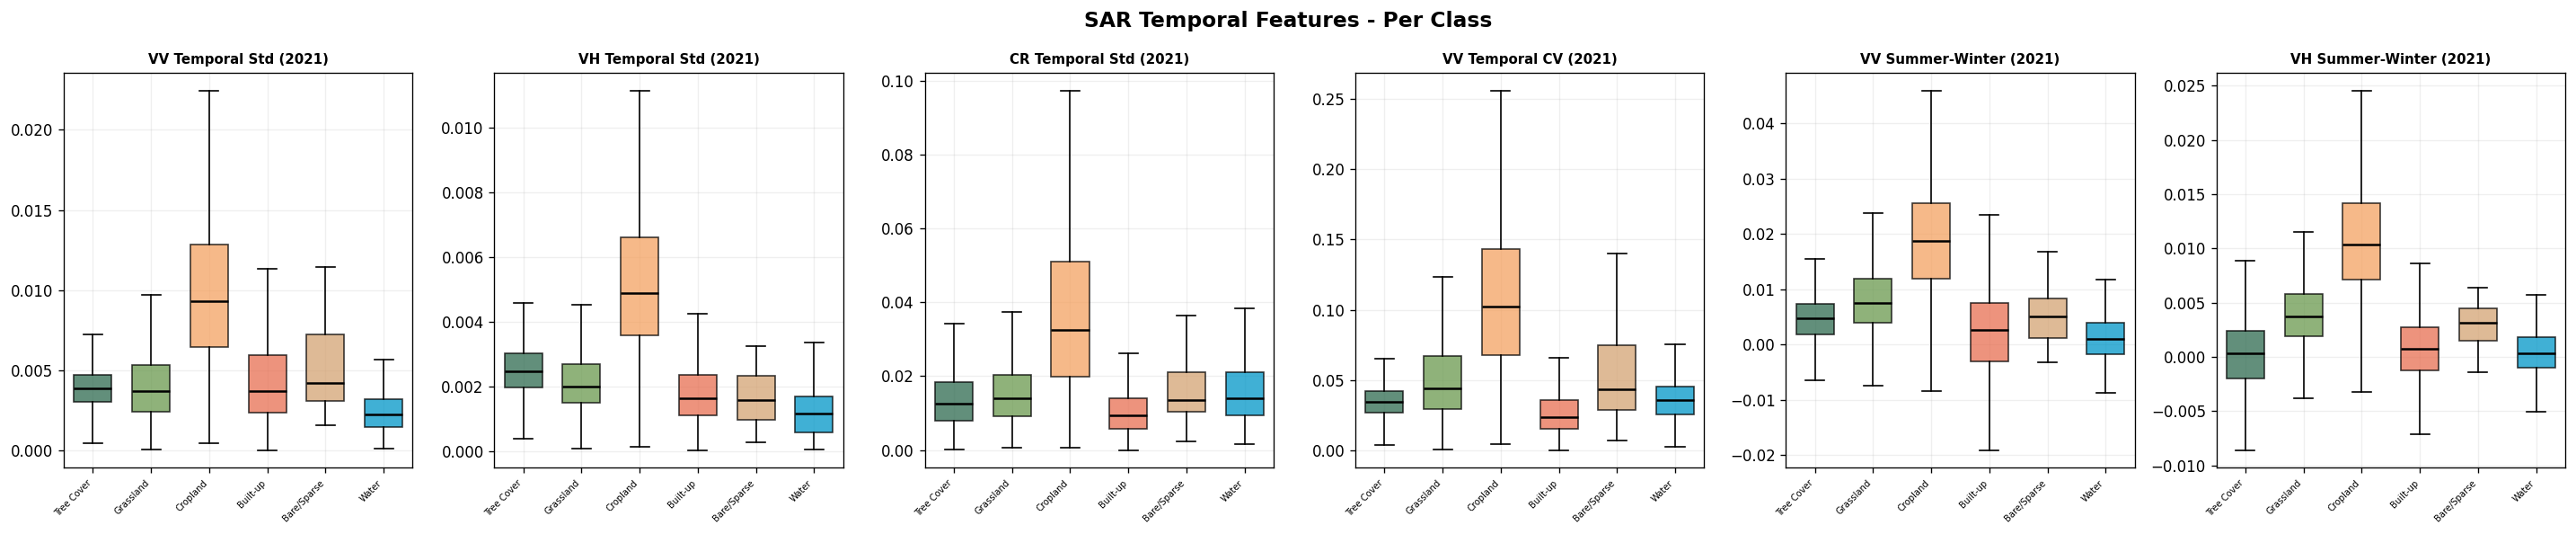

In [10]:
temporal_sar = {
    'SAR_VV_temporal_std': 'VV Temporal Std',
    'SAR_VH_temporal_std': 'VH Temporal Std',
    'SAR_CR_temporal_std': 'CR Temporal Std',
    'SAR_VV_temporal_cv': 'VV Temporal CV',
    'SAR_VV_summer_winter': 'VV Summer-Winter',
    'SAR_VH_summer_winter': 'VH Summer-Winter',
}

avail_sar = {}
for key, label in temporal_sar.items():
    for year in ['2021', '2020']:
        col = f'{key}_{year}'
        if col in df.columns:
            avail_sar[col] = f'{label} ({year})'
            break

n = len(avail_sar)
if n > 0:
    fig, axes = plt.subplots(1, min(n, 6), figsize=(4*min(n,6), 5))
    if n == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, list(avail_sar.items())[:6]):
        data = [df.loc[df.label == c, col].dropna().values for c in classes]
        data_f = [d for d in data if len(d) > 0]

        bp = ax.boxplot(data_f, patch_artist=True, showfliers=False, widths=0.65)
        for patch, co in zip(bp['boxes'], colors_used):
            patch.set_facecolor(co)
            patch.set_alpha(0.75)
        for med in bp['medians']:
            med.set_color('black')
            med.set_linewidth(1.5)

        ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=6)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)

    plt.suptitle('SAR Temporal Features - Per Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DIAG_DIR / 'eda_sar_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No temporal SAR features found')

## 10. Texture & Tasseled Cap Features

- **Edge features** capture spatial heterogeneity (urban areas are more textured)
- **Tasseled Cap** transforms: brightness (soil/urban), greenness (vegetation), wetness (moisture)

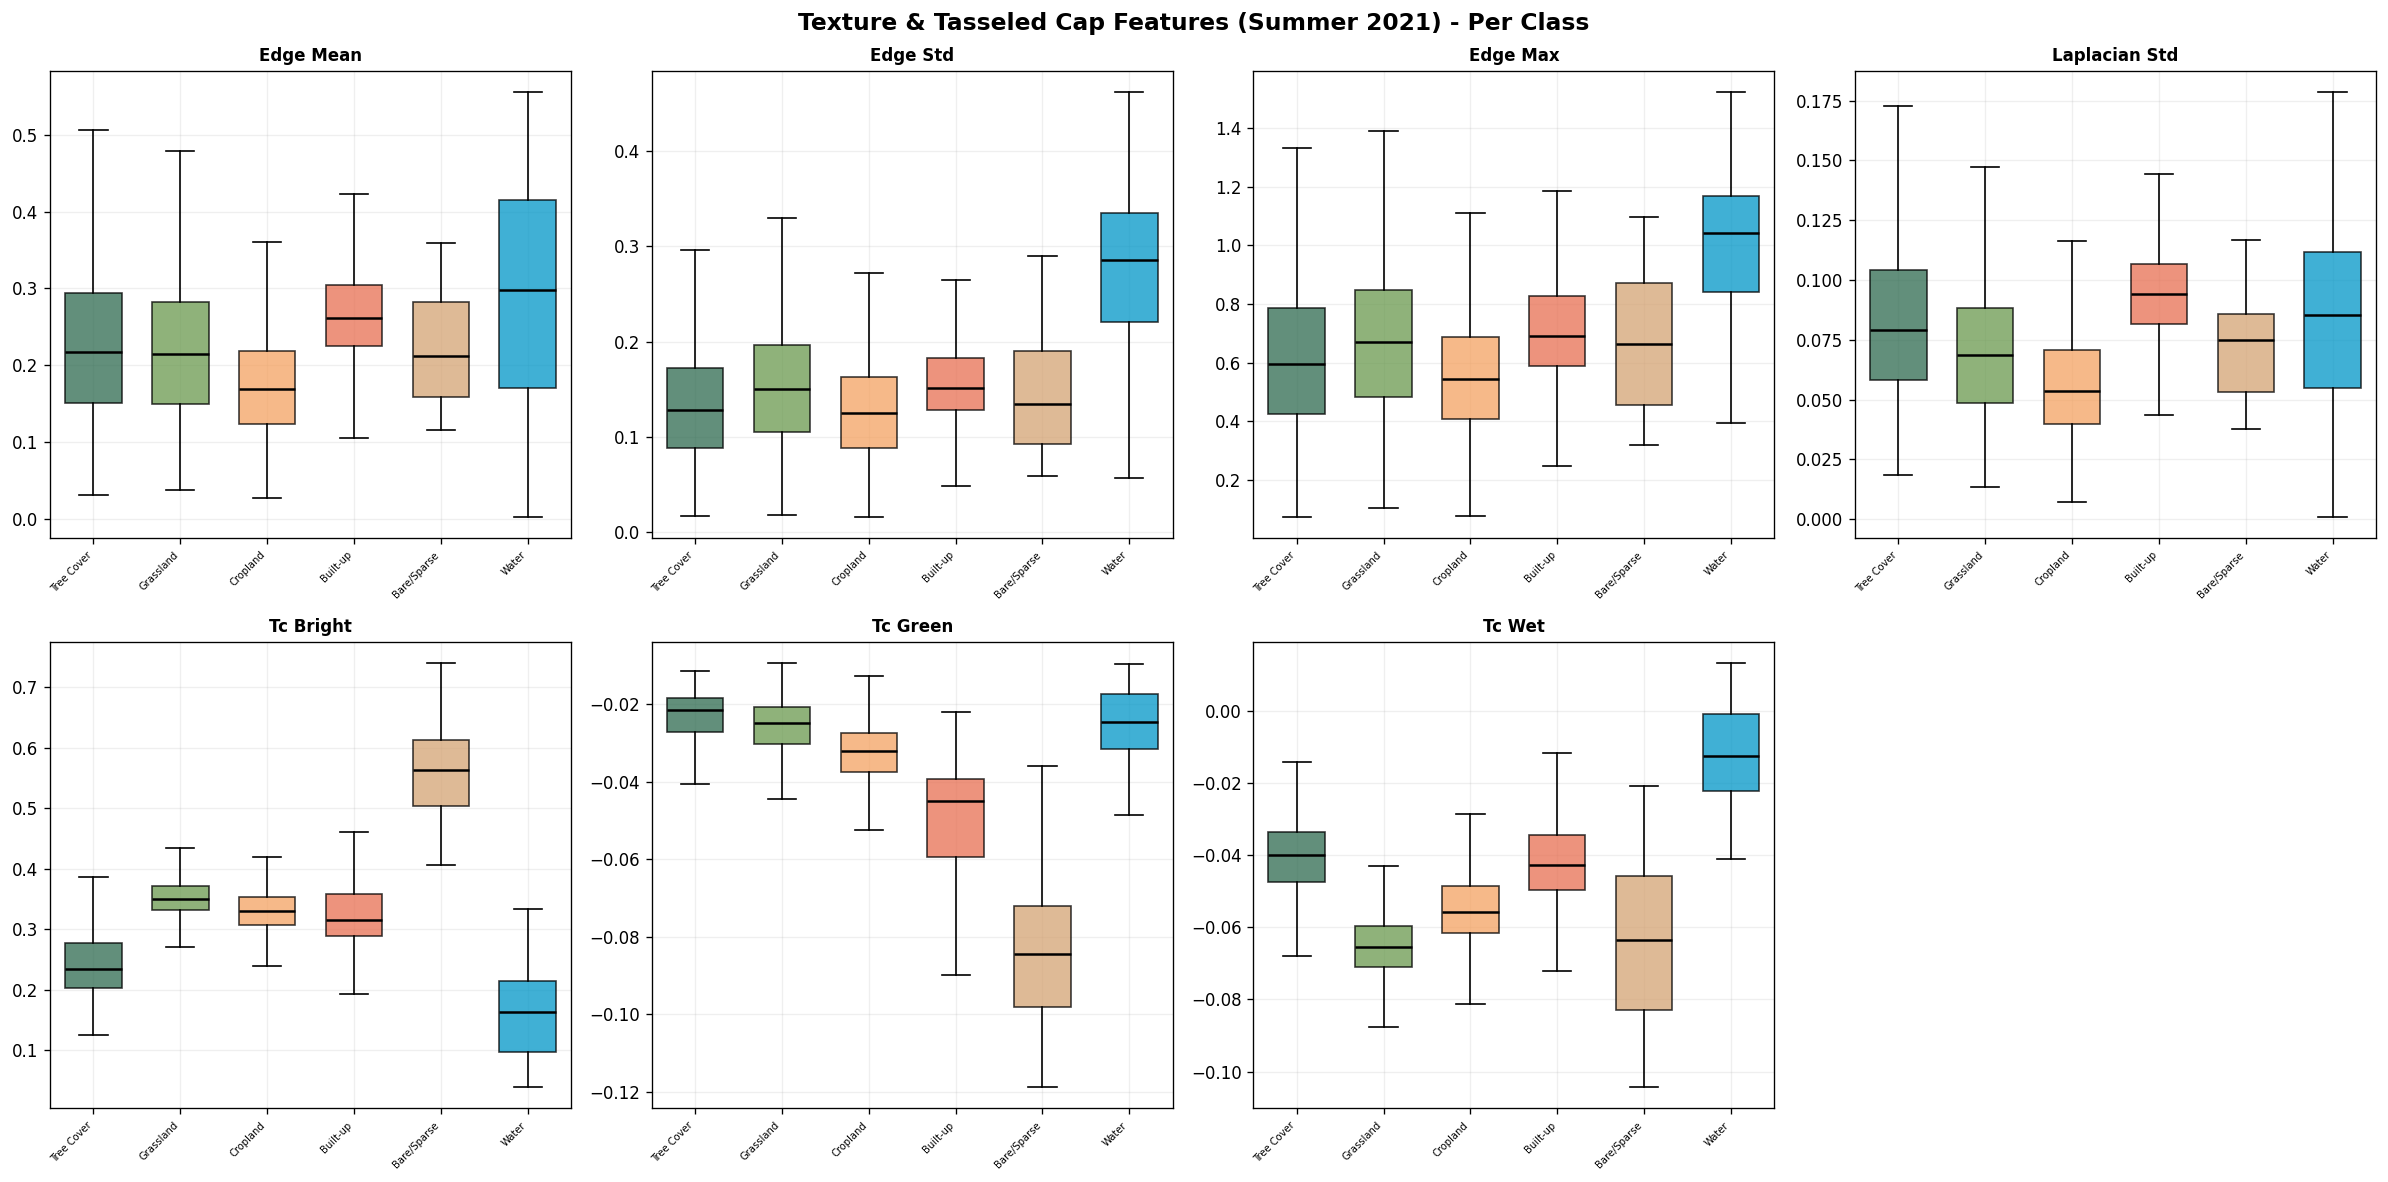

In [11]:
texture_feats = {
    'edge_mean': 'Edge Mean',
    'edge_std': 'Edge Std',
    'edge_max': 'Edge Max',
    'lap_std': 'Laplacian Std',
}

tc_feats = {}
for c in feature_cols:
    if c.startswith('TC_') and '_mean_2021_summer' in c:
        nice = c.replace('_mean_2021_summer', '').replace('TC_', 'TC ')
        tc_feats[c] = nice.title()

# Combine texture + TC
all_text = {}
for key, label in texture_feats.items():
    col = f'{key}_2021_summer'
    if col in df.columns:
        all_text[col] = label
all_text.update(tc_feats)

n = len(all_text)
if n > 0:
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    if n == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (col, label) in zip(axes_flat, all_text.items()):
        data = [df.loc[df.label == c, col].dropna().values for c in classes]
        data_f = [d for d in data if len(d) > 0]

        bp = ax.boxplot(data_f, patch_artist=True, showfliers=False, widths=0.65)
        for patch, co in zip(bp['boxes'], colors_used):
            patch.set_facecolor(co)
            patch.set_alpha(0.75)
        for med in bp['medians']:
            med.set_color('black')
            med.set_linewidth(1.5)

        ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=6)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.2)

    for i in range(len(all_text), len(axes_flat)):
        axes_flat[i].set_visible(False)

    plt.suptitle('Texture & Tasseled Cap Features (Summer 2021) - Per Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DIAG_DIR / 'eda_texture_tc.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No texture features found')

## 11. Feature Correlation Heatmap

Correlation between representative features (mean, summer 2021) to identify redundancy.

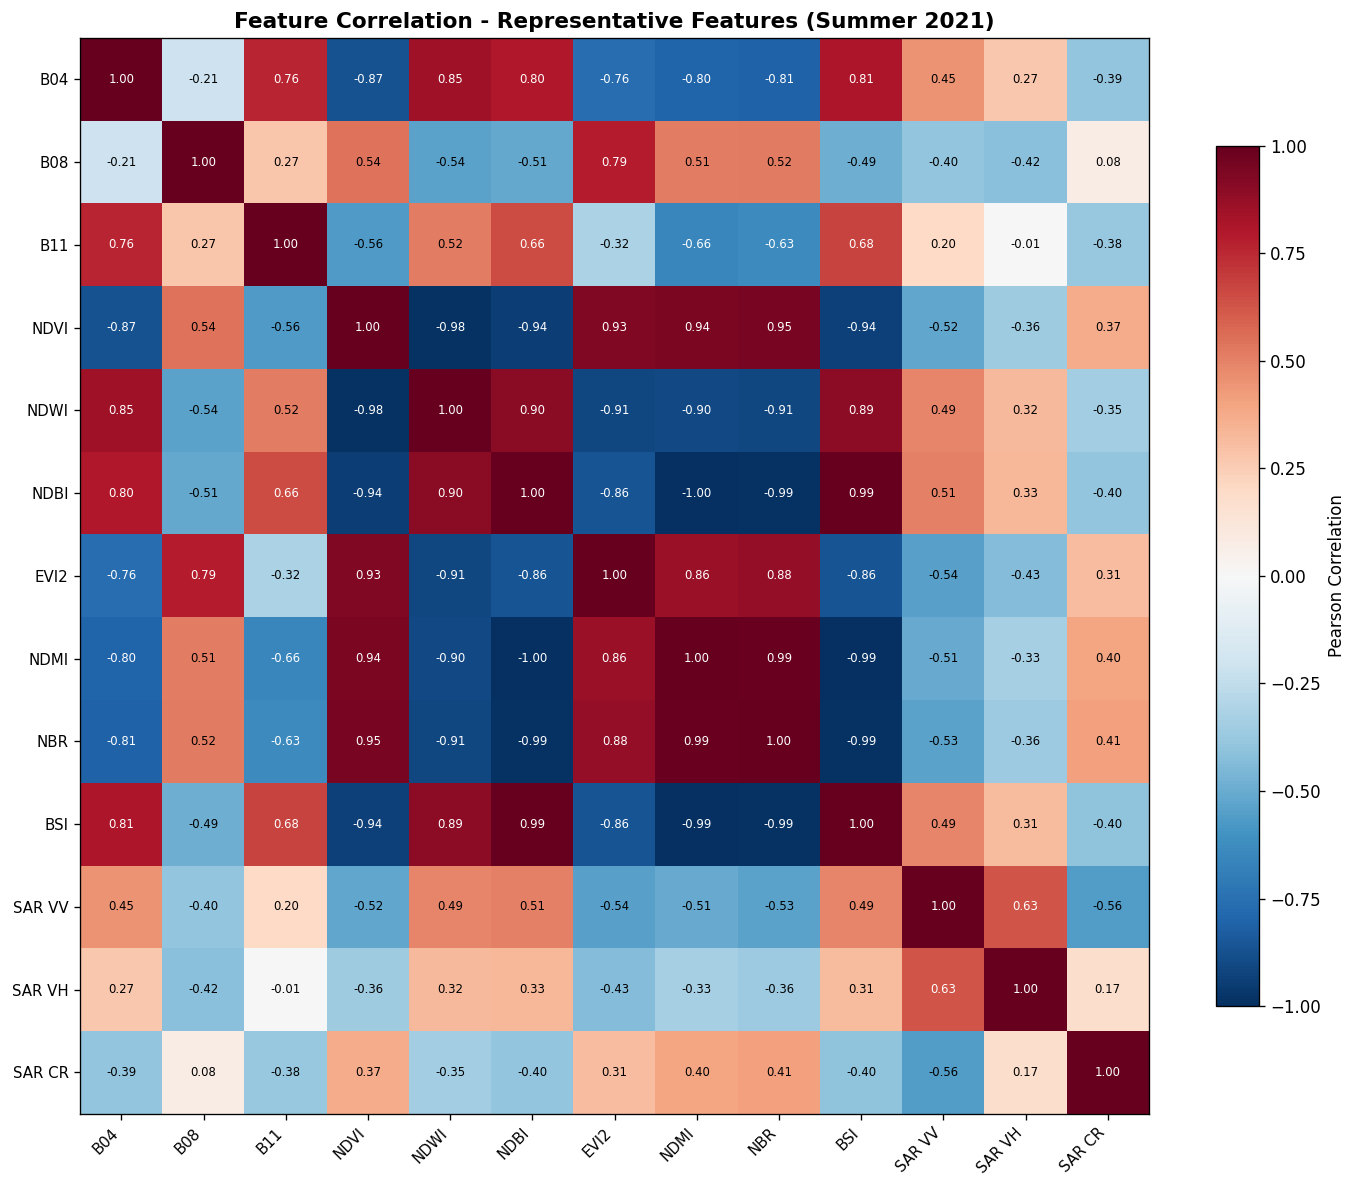

In [12]:
# Select representative features
rep_feats = []
for band in ['B04', 'B08', 'B11']:
    c = f'{band}_mean_2021_summer'
    if c in df.columns:
        rep_feats.append(c)
for idx in ['NDVI', 'NDWI', 'NDBI', 'EVI2', 'NDMI', 'NBR', 'BSI']:
    c = f'{idx}_mean_2021_summer'
    if c in df.columns:
        rep_feats.append(c)
for sar in ['SAR_VV', 'SAR_VH', 'SAR_CR']:
    c = f'{sar}_mean_2021_summer'
    if c in df.columns:
        rep_feats.append(c)

corr = df[rep_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

nice_labels = [c.replace('_mean_2021_summer', '').replace('SAR_', 'SAR ') for c in rep_feats]
ax.set_xticks(range(len(rep_feats)))
ax.set_yticks(range(len(rep_feats)))
ax.set_xticklabels(nice_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(nice_labels, fontsize=9)

for i in range(len(rep_feats)):
    for j in range(len(rep_feats)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Pearson Correlation', shrink=0.8)
ax.set_title('Feature Correlation - Representative Features (Summer 2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Year-over-Year Comparison (2020 vs 2021)

How consistent are features between the two input years? High consistency = stable features.

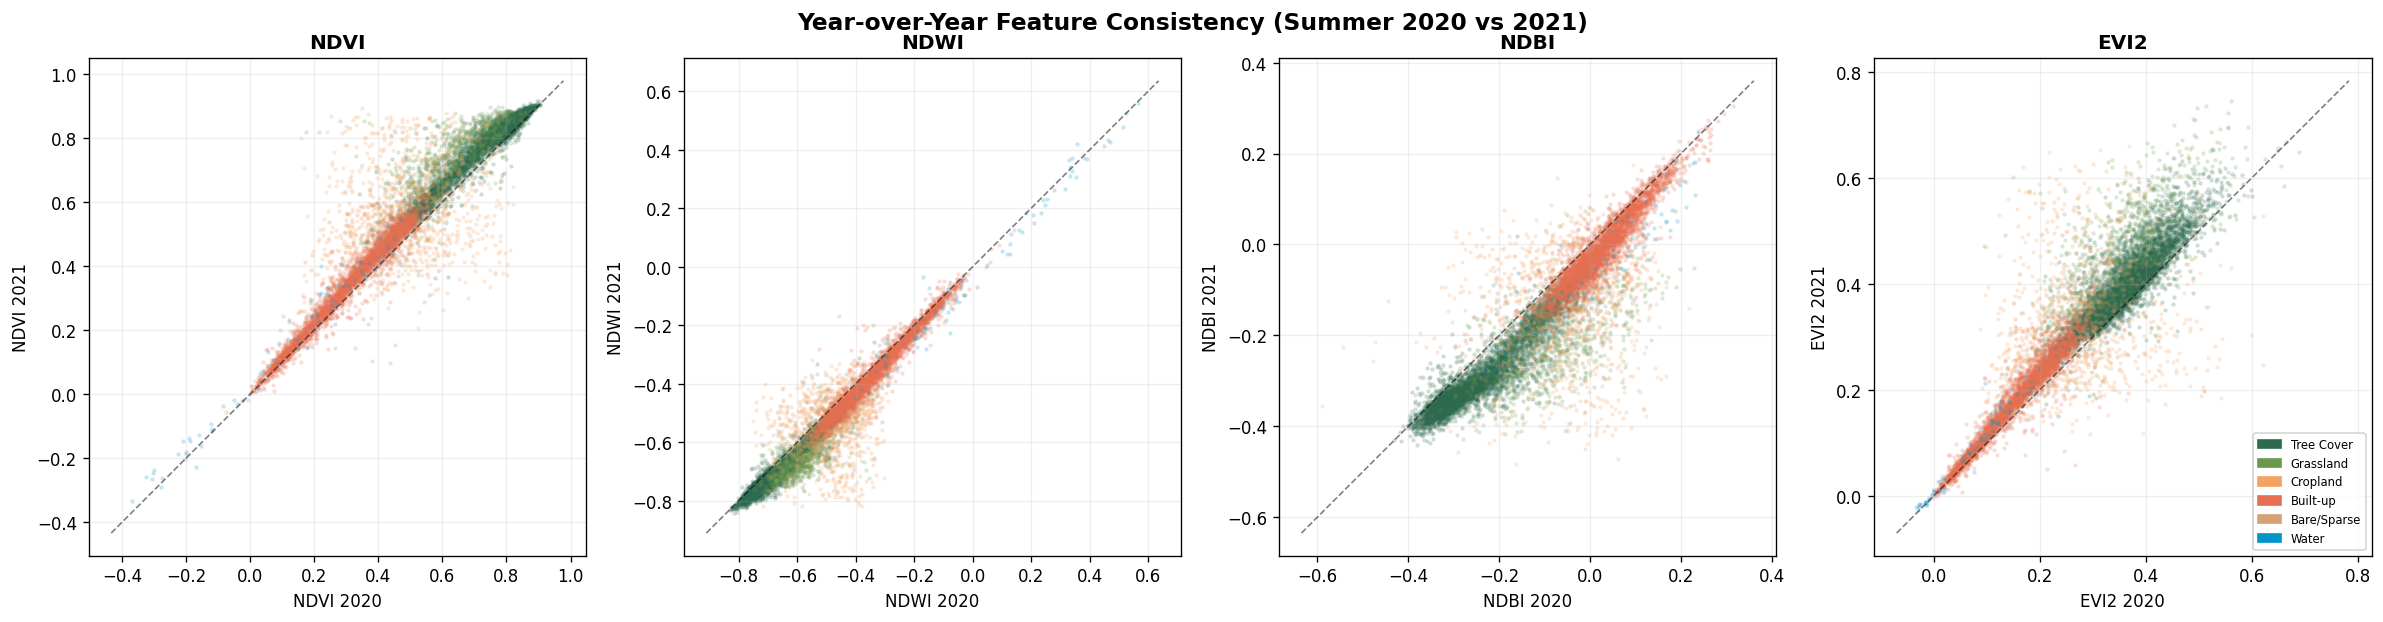

In [13]:
compare_indices = ['NDVI', 'NDWI', 'NDBI', 'EVI2']

fig, axes = plt.subplots(1, len(compare_indices), figsize=(5*len(compare_indices), 5))

for ax, idx in zip(axes, compare_indices):
    col_2020 = f'{idx}_mean_2020_summer'
    col_2021 = f'{idx}_mean_2021_summer'
    if col_2020 not in df.columns or col_2021 not in df.columns:
        continue

    for c, name, color in zip(classes, class_labels_used, colors_used):
        mask = df.label == c
        x = df.loc[mask, col_2020].values
        y = df.loc[mask, col_2021].values
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() > 100:
            ax.scatter(x[valid][::3], y[valid][::3], c=color, alpha=0.15, s=3, label=name)

    lims = [ax.get_xlim(), ax.get_ylim()]
    lo = min(lims[0][0], lims[1][0])
    hi = max(lims[0][1], lims[1][1])
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, lw=1)

    ax.set_xlabel(f'{idx} 2020')
    ax.set_ylabel(f'{idx} 2021')
    ax.set_title(idx, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

handles = [mpatches.Patch(color=c, label=n) for c, n in zip(colors_used, class_labels_used)]
axes[-1].legend(handles=handles, fontsize=7, loc='lower right')

plt.suptitle('Year-over-Year Feature Consistency (Summer 2020 vs 2021)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_year_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. S2 Band Statistics Comparison

Comparing different statistics (mean, std, median) for a single band across classes reveals
how variability differs between land cover types.

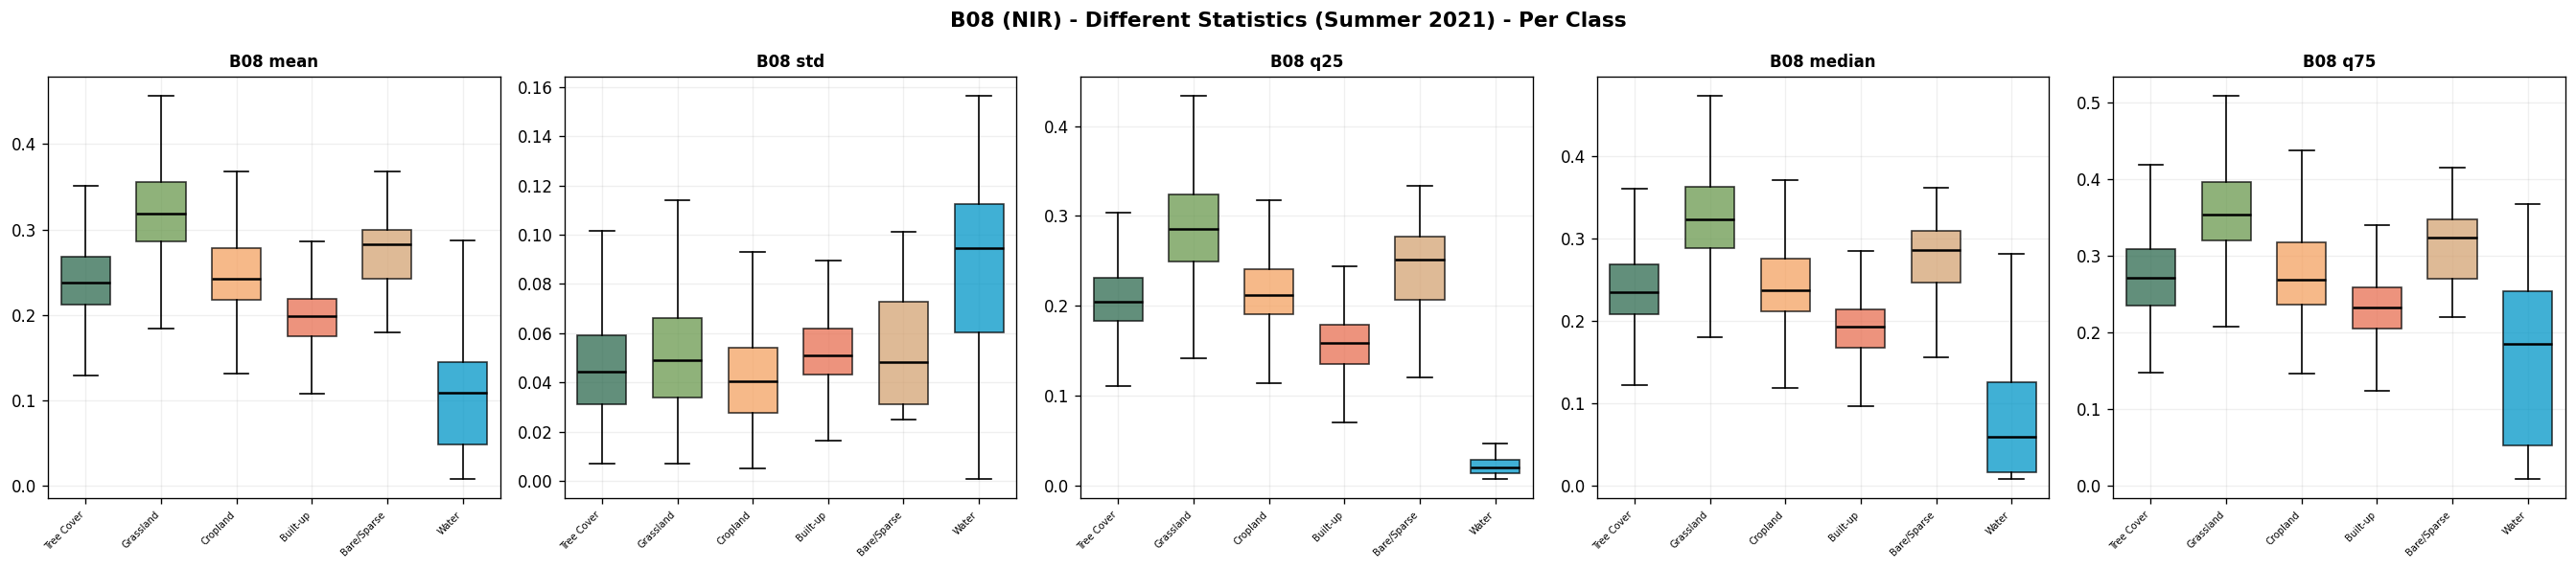

In [14]:
# Pick B08 (NIR) as representative
band = 'B08'
stats = ['mean', 'std', 'q25', 'median', 'q75']
stats_avail = [s for s in stats if f'{band}_{s}_2021_summer' in df.columns]

fig, axes = plt.subplots(1, len(stats_avail), figsize=(4.5*len(stats_avail), 5))
if len(stats_avail) == 1:
    axes = [axes]

for ax, stat in zip(axes, stats_avail):
    col = f'{band}_{stat}_2021_summer'
    data = [df.loc[df.label == c, col].dropna().values for c in classes]
    data_f = [d for d in data if len(d) > 0]

    bp = ax.boxplot(data_f, patch_artist=True, showfliers=False, widths=0.65)
    for patch, co in zip(bp['boxes'], colors_used):
        patch.set_facecolor(co)
        patch.set_alpha(0.75)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1.5)

    ax.set_xticklabels(class_labels_used, rotation=45, ha='right', fontsize=6)
    ax.set_title(f'{band} {stat}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle(f'{band} (NIR) - Different Statistics (Summer 2021) - Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'eda_b08_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Summary Statistics Table

In [15]:
summary_feats = ['NDVI_mean_2021_summer', 'NDWI_mean_2021_summer', 'NDBI_mean_2021_summer',
                 'EVI2_mean_2021_summer', 'B04_mean_2021_summer', 'B08_mean_2021_summer',
                 'B11_mean_2021_summer', 'SAR_VV_mean_2021_summer', 'SAR_VH_mean_2021_summer']
summary_feats = [f for f in summary_feats if f in df.columns]

summary = df.groupby('label_name')[summary_feats].mean()
nice_cols = [c.replace('_mean_2021_summer', '').replace('SAR_', 'SAR ') for c in summary_feats]
summary.columns = nice_cols

print('Per-class mean feature values (Summer 2021):')
display(summary.round(4).style.background_gradient(cmap='YlOrRd', axis=0))

Per-class mean feature values (Summer 2021):


,NDVI,NDWI,NDBI,EVI2,B04,B08,B11,SAR VV,SAR VH
label_name,,,,,,,,,
Bare/Sparse,0.210600,-0.290400,0.051300,0.131400,0.191200,0.277700,0.310600,0.118500,0.046400
Built-up,0.349000,-0.367900,-0.006800,0.180700,0.096900,0.198500,0.188400,0.178400,0.075600
Cropland,0.560400,-0.535200,-0.134200,0.323500,0.068500,0.252000,0.187900,0.100200,0.046700
Grassland,0.728100,-0.639300,-0.219700,0.474600,0.048100,0.322500,0.200600,0.090000,0.044500
Tree Cover,0.774000,-0.699600,-0.286700,0.399600,0.030600,0.242200,0.133200,0.119200,0.061800
Water,0.159600,-0.020100,-0.043800,0.102300,0.043700,0.100400,0.075700,0.075300,0.038400


## Key Findings

1. **NDVI** is the strongest class discriminator — tree cover has the highest NDVI (~0.8), followed by grassland (~0.75); water is near zero (~0.2), built-up is low (~0.35)
2. **NDBI** (built-up index) separates urban and bare surfaces (positive values) from vegetated classes (negative values), though with overlapping distributions
3. **SAR VV/VH** shows urban double-bounce scattering (built-up has the highest backscatter at ~0.17 VV), while water has the lowest due to specular reflection (~0.07 VV). Cross-ratio is highest for water, indicating strong depolarization
4. **Seasonal NDVI profiles** show all vegetation classes increasing from spring to summer; cropland shows the largest seasonal swing (0.48 → 0.55), while tree cover and grassland remain relatively stable at high values
5. **Feature redundancy is extreme**: NDBI-BSI correlation = 0.99, NDMI-NBR = 0.99, NDVI-EVI2 = 0.93. Many spectral indices carry near-identical information, though the model may still benefit from this for robustness
6. **Year consistency**: features are generally stable between 2020-2021, confirming temporal consistency of the input data
7. **Class imbalance in Nuremberg**: tree cover dominates (47.9%, 14.4K cells), followed by built-up (33.2%, 9.9K cells); bare/sparse (28 cells, 0.1%) and water (247 cells, 0.8%) are extreme minority classes